In [70]:
import pandas as pd
import numpy as np

In [69]:
import pandas as pd

crop = pd.read_csv("Crop_recommendation.csv")

In [73]:


x = crop.drop("label", axis=1)
y = crop["label"]

print(x["rainfall"].describe())
print(x["rainfall"].head(20))

count    2200.000000
mean      103.463655
std        54.958389
min        20.211267
25%        64.551686
50%        94.867624
75%       124.267508
max       298.560117
Name: rainfall, dtype: float64
0     202.935536
1     226.655537
2     263.964248
3     242.864034
4     262.717340
5     251.055000
6     271.324860
7     241.974195
8     230.446236
9     221.209196
10    264.614870
11    250.083234
12    284.436457
13    185.277339
14    209.586971
15    231.086335
16    276.655246
17    206.261186
18    224.555017
19    291.298662
Name: rainfall, dtype: float64


In [3]:
print(type(crop))

<class 'pandas.core.frame.DataFrame'>


In [4]:
print(crop["label"].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [5]:
crop = pd.read_csv("Crop_recommendation.csv")
print(crop.shape)

(2200, 8)


In [6]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
print(crop)

        N   P   K  temperature   humidity        ph    rainfall   label
0      90  42  43    20.879744  82.002744  6.502985  202.935536    rice
1      85  58  41    21.770462  80.319644  7.038096  226.655537    rice
2      60  55  44    23.004459  82.320763  7.840207  263.964248    rice
3      74  35  40    26.491096  80.158363  6.980401  242.864034    rice
4      78  42  42    20.130175  81.604873  7.628473  262.717340    rice
...   ...  ..  ..          ...        ...       ...         ...     ...
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.225123  6.362608  173.322839  coffee
2198  117  32  34    26.272418  52.127394  6.758793  127.175293  coffee
2199  104  18  30    23.603016  60.396475  6.779833  140.937041  coffee

[2200 rows x 8 columns]


In [8]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [9]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [10]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
corr = crop.corr(numeric_only=True)
corr

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


<Axes: >

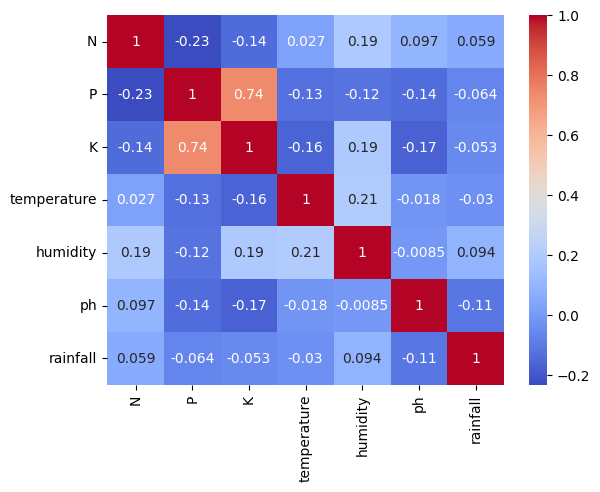

In [12]:
import seaborn as sns
sns.heatmap(corr,annot=True,cbar=True, cmap="coolwarm")

In [13]:
crop["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

C:\Users\Diamond Technology\AppData\Local\Temp\ipykernel_100\2489763507.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(crop["N"])


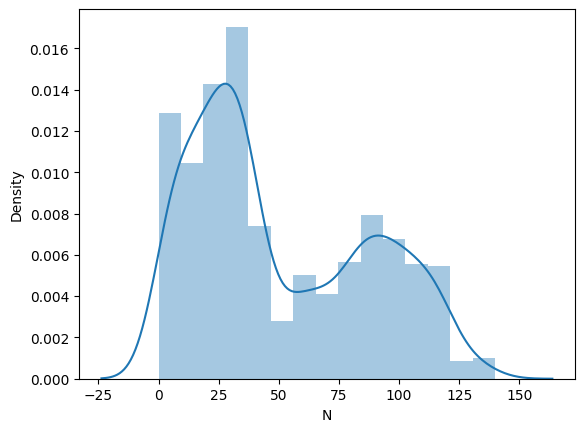

In [14]:
import matplotlib.pyplot as plt
sns.distplot(crop["N"])
plt.show()

In [15]:
print(crop["label"].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [16]:
crop_dict = {
    "rice" : 1,
    "maize" : 2,
    "jute" :3,
    "cotton" : 4,
    "coconut" : 5,
    "papaya" : 6,
    "orange" : 7,
    "apple" : 8,
    "muskmelon" :9,
    "watermelon": 10,
    "grapes" : 11,
    "mango" : 12,
    "banana" : 13,
    "pomegranate" : 14,
    "lentil" : 15,
    "blackgram" : 16,
    "mungbean" : 17,
    "mothbeans" : 18,
    "pigeonpeas" : 19,
    "kidneybeans" : 20,
    "coffee" : 21,
    "chickpea" : 22

}
crop["crop_num"] = crop["label"].map(crop_dict)

In [17]:
crop["crop_num"].value_counts()

crop_num
1     100
2     100
22    100
20    100
19    100
18    100
17    100
16    100
15    100
14    100
13    100
12    100
11    100
10    100
9     100
8     100
7     100
6     100
5     100
4     100
3     100
21    100
Name: count, dtype: int64

In [18]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


In [19]:
x = crop.drop(["label", "crop_num"], axis=1)

y = crop["crop_num"]

In [74]:
rainfall_by_crop = crop.groupby("label")["rainfall"].agg(
    ["min", "max", "mean", "median"]
).sort_values("mean")

print(rainfall_by_crop)

                    min         max        mean      median
label                                                      
muskmelon     20.211267   29.866814   24.689952   24.721512
lentil        35.034848   54.939377   45.680454   46.553255
mungbean      36.120429   59.872321   48.403601   49.028171
watermelon    40.126504   59.759800   50.786219   50.671903
mothbeans     30.920140   74.443307   51.198487   51.182738
blackgram     60.417903   74.915595   67.884151   68.293539
grapes        65.010953   74.915062   69.611829   69.536186
chickpea      65.113656   94.781896   80.058977   79.692282
cotton        60.653817   99.931008   80.398043   80.237095
maize         60.651715  109.751538   84.766988   83.471553
mango         89.291476  100.812466   94.704515   94.905973
banana        90.109781  119.847970  104.626980  105.007750
kidneybeans   60.275525  149.744103  105.919778  107.399392
pomegranate  102.518476  112.475094  107.528442  107.588201
orange       100.173796  119.694658  110

In [75]:
print(x.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [20]:
print(crop[["crop_num", "label"]].drop_duplicates().sort_values("crop_num"))

      crop_num        label
0            1         rice
100          2        maize
2000         3         jute
1900         4       cotton
1800         5      coconut
1700         6       papaya
1600         7       orange
1500         8        apple
1400         9    muskmelon
1300        10   watermelon
1200        11       grapes
1100        12        mango
1000        13       banana
900         14  pomegranate
800         15       lentil
700         16    blackgram
600         17     mungbean
500         18    mothbeans
400         19   pigeonpeas
300         20  kidneybeans
2100        21       coffee
200         22     chickpea


In [21]:
y.shape

(2200,)

In [22]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
x_train.shape

(1760, 7)

In [24]:
x_test.shape

(440, 7)

In [25]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

In [26]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [27]:
import pickle

pickle.dump(ms, open("scaler.pkl", "wb"))
pickle.dump(nb, open("model.pkl", "wb"))   # অথবা rf

In [28]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(sc, open("scaler.pkl", "wb"))

In [31]:
from sklearn.metrics import accuracy_score

pred = rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9954545454545455


In [32]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


sc.fit(x_train)
x_train = sc.transform(x_train)
x_test = sc.transform(x_test)
x_train

array([[-0.53485601, -0.06774701, -0.45707254, ...,  0.630978  ,
         0.95283309, -0.91715966],
       [-1.0226846 ,  2.20830422,  3.07735551, ...,  0.95515406,
        -0.10530336,  0.07938741],
       [ 1.63327107, -1.43337774,  0.09579889, ...,  0.76651605,
        -0.19591057, -1.04280418],
       ...,
       [ 1.28095042, -1.40303039, -0.06216438, ...,  0.94233444,
        -0.39852411, -1.38982378],
       [ 0.87442659, -1.1602516 ,  0.01681725, ...,  0.89222474,
        -0.03399582, -1.45582319],
       [-1.13109095,  2.72420916,  2.93913765, ...,  0.95898061,
        -1.16287487,  0.25057935]], shape=(1760, 7))

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression" : LogisticRegression(),
    "Naive Bayes" : GaussianNB(),
    "Support Vector Machine" : SVC(),
    "K-nearest Neighbors" : KNeighborsClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random forest" : RandomForestClassifier(),
    "Bagging" : BaggingClassifier(),
    "AdaBoost" : AdaBoostClassifier(),
    "Extra Trees" : ExtraTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}

for name, md in models.items():
    md.fit(x_train,y_train)
    ypred = md.predict(x_test)
    
    print(f"{name} with accuracy : {accuracy_score(y_test,ypred)}")



Logistic Regression with accuracy : 0.975
Naive Bayes with accuracy : 0.9954545454545455
Support Vector Machine with accuracy : 0.9772727272727273
K-nearest Neighbors with accuracy : 0.9772727272727273
Decision Tree with accuracy : 0.9818181818181818
Random forest with accuracy : 1.0
Bagging with accuracy : 0.9931818181818182
AdaBoost with accuracy : 0.26590909090909093
Extra Trees with accuracy : 0.9136363636363637
Gradient Boosting with accuracy : 0.9931818181818182


In [34]:
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)
ypred = rfc.predict(x_test)
accuracy_score(y_test,ypred)

1.0

In [35]:
def recommendation(N,P,K,temperature,humidity,ph,rainfall):
    features = np.array([[N,P,K,temperature,humidity,ph,rainfall]])
    prediction = rfc.predict(features).reshape(1,-1)
    
    return prediction[0]

In [36]:
N = 20
P = 30
K = 40
temperature = 40.0
humidity = 20.0
ph = 30.0
rainfall = 50.0

predict = recommendation(N, P, K, temperature, humidity, ph, rainfall)

crop_dict = {
    1: "rice", 2: "maize", 3: "jute", 4: "cotton", 5: "coconut",
    6: "papaya", 7: "orange", 8: "apple", 9: "muskmelon",
    10: "watermelon", 11: "grapes", 12: "mango", 13: "banana",
    14: "pomegranate", 15: "lentil", 16: "blackgram",
    17: "mungbean", 18: "mothbeans", 19: "pigeonpeas",
    20: "kidneybeans", 21: "coffee", 22: "chickpea"
}

if predict[0] in crop_dict:
    predicted_crop = crop_dict[predict[0]]
    result = f"{predicted_crop} is the best crop to be cultivated"
    print(result)
else:
    print("Sorry, we are not able to recommend a proper crop for this environment.")

apple is the best crop to be cultivated


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

import pickle
pickle.dump(rf, open("model.pkl", "wb"))

In [38]:
print(type(crop))

<class 'pandas.core.frame.DataFrame'>


In [39]:
print(crop["label"].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [40]:
print(crop["label"].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [41]:
print(crop["label"].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [42]:
print(y.unique())

[ 1  2 22 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3 21]


In [43]:
print(y_test[:20].values)

[17  2  7 12 17  4 21  3  2 17 22 20 22 12 14  8  8 13 13  1]


In [44]:
dir()

['AdaBoostClassifier',
 'BaggingClassifier',
 'DecisionTreeClassifier',
 'ExtraTreeClassifier',
 'GaussianNB',
 'GradientBoostingClassifier',
 'In',
 'K',
 'KNeighborsClassifier',
 'LogisticRegression',
 'MinMaxScaler',
 'N',
 'Out',
 'P',
 'RandomForestClassifier',
 'SVC',
 'StandardScaler',
 '_',
 '_10',
 '_11',
 '_12',
 '_13',
 '_17',
 '_18',
 '_21',
 '_23',
 '_24',
 '_26',
 '_29',
 '_32',
 '_34',
 '_6',
 '_9',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accur

In [45]:
for name, md in models.items():
    md.fit(x_train, y_train)
    ypred = md.predict(x_test)

    print(f"{name} with accuracy : {accuracy_score(y_test, ypred)}")

Logistic Regression with accuracy : 0.975
Naive Bayes with accuracy : 0.9954545454545455
Support Vector Machine with accuracy : 0.9772727272727273
K-nearest Neighbors with accuracy : 0.9772727272727273
Decision Tree with accuracy : 0.9795454545454545
Random forest with accuracy : 0.9977272727272727
Bagging with accuracy : 0.9863636363636363
AdaBoost with accuracy : 0.3181818181818182
Extra Trees with accuracy : 0.9181818181818182
Gradient Boosting with accuracy : 0.9931818181818182


In [46]:
from sklearn.naive_bayes import GaussianNB
import pickle

nb = GaussianNB()
nb.fit(x_train, y_train)

pickle.dump(nb, open("model.pkl", "wb"))

In [47]:
from sklearn.ensemble import RandomForestClassifier
import pickle

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

pickle.dump(rf, open("model.pkl", "wb"))

In [48]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [49]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(sc, open("scaler.pkl", "wb"))

In [50]:
pickle.dump(ms, open("scaler.pkl", "wb"))

In [51]:

import os

print(os.listdir())

['Crop_recommendation.csv', 'Crop_recommendation.ipynb', 'model.pkl', 'scaler.pkl']


In [52]:
print(rf.predict(x_test[:10]))
print(y_test.iloc[:10].values)

[17  2  7 12 17  4 21  3  2 17]
[17  2  7 12 17  4 21  3  2 17]


In [53]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [54]:
import pickle

pickle.dump(ms, open("scaler.pkl", "wb"))

In [55]:
print(crop["label"].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [56]:
import os

print(os.getcwd())

d:\crop recommendation\notebooks


In [57]:
import os

print(os.listdir())

['Crop_recommendation.csv', 'Crop_recommendation.ipynb', 'model.pkl', 'scaler.pkl']


In [58]:
print(model.predict(x_test[:20]))

[17  2  7 12 17  4 21  3  2 17 22 20 22 12 14  8  8 13 13  1]


In [59]:
x = crop.drop(["label", "crop_num"], axis=1)
y = crop["crop_num"]

In [60]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [62]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [63]:
print("Accuracy:", nb.score(x_test, y_test))

Accuracy: 0.9954545454545455


In [64]:
from sklearn.metrics import accuracy_score

pred = nb.predict(x_test)

print("Accuracy :", accuracy_score(y_test, pred))

Accuracy : 0.9954545454545455


In [65]:
import pickle

pickle.dump(nb, open("model.pkl", "wb"))
pickle.dump(sc, open("scaler.pkl", "wb"))

In [66]:
print(nb.predict(x_test[:20]))
print(y_test.iloc[:20].values)


[17  2  7 12 17  4 21  3  2 17 22 20 22 12 14  8  8 13 13  1]
[17  2  7 12 17  4 21  3  2 17 22 20 22 12 14  8  8 13 13  1]


In [67]:
pred = nb.predict(x_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9954545454545455
